In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

%matplotlib inline

# Caminho da pasta onde estão os CSVs.
BASE_PATH = Path('/content/drive/MyDrive/POSTECH - [DTAT] - Tech Challenge - Fase 1')

# Alternativa para rodar no GitHub/local: se existir uma pasta data/, usa ela automaticamente.
if not BASE_PATH.exists():
    BASE_PATH = Path('data')

# Alternativa para rodar com os CSVs na mesma pasta do notebook.
if not BASE_PATH.exists():
    BASE_PATH = Path('.')

print('Base utilizada:', BASE_PATH.resolve())


Base utilizada: /content/drive/MyDrive/POSTECH - [DTAT] - Tech Challenge - Fase 1


1. Lendo as tabelas

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
df_clientes = pd.read_csv(BASE_PATH / 'olist_customers_dataset.csv')
df_pedidos = pd.read_csv(BASE_PATH / 'olist_orders_dataset.csv')
df_itens = pd.read_csv(BASE_PATH / 'olist_order_items_dataset.csv')
df_geo = pd.read_csv(BASE_PATH / 'olist_geolocation_dataset.csv')

# Tabelas complementares usadas para validação e indicadores adicionais.
df_reviews = pd.read_csv(BASE_PATH / 'olist_order_reviews_dataset.csv')

df_clientes.head()


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


2. Unindo as tabelas


In [ ]:
itens_por_pedido = df_itens.groupby('order_id').agg(
    frete_total=('freight_value', 'sum'),
    receita_produtos=('price', 'sum'),
    qtd_itens=('order_item_id', 'max'),
    qtd_sellers=('seller_id', 'nunique')
).reset_index()

# Unindo pedidos com clientes e depois com a tabela de itens já agregada por pedido.
df_mestra = (
    df_pedidos
    .merge(df_clientes[['customer_id', 'customer_state', 'customer_city']], on='customer_id', how='left')
    .merge(itens_por_pedido, on='order_id', how='left')
)

df_mestra.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_state,customer_city,frete_total,receita_produtos,qtd_itens,qtd_sellers
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,SP,sao paulo,8.72,29.99,1.0,1.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,BA,barreiras,22.76,118.70,1.0,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,GO,vianopolis,19.22,159.90,1.0,1.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,RN,sao goncalo do amarante,27.20,45.00,1.0,1.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,SP,santo andre,8.72,19.90,1.0,1.0


3. Convertendo as colunas de datas para o formato correto de Python


In [ ]:
colunas_datas = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for coluna in colunas_datas:
    df_mestra[coluna] = pd.to_datetime(df_mestra[coluna], errors='coerce')


4. Calculando o Lead Time

In [ ]:
# Calculando a diferença em dias entre a compra e a entrega real.
# Usamos total_seconds()/86400 para preservar casas decimais
df_mestra['tempo_entrega_real'] = (
    df_mestra['order_delivered_customer_date'] - df_mestra['order_purchase_timestamp']
).dt.total_seconds() / 86400

# Calculando a diferença entre a estimativa e a entrega real.
# Valor positivo = atraso; valor negativo = chegou antes do previsto.
df_mestra['atraso_entrega'] = (
    df_mestra['order_delivered_customer_date'] - df_mestra['order_estimated_delivery_date']
).dt.total_seconds() / 86400


5. Calculando tempo de processamento e deslocamento

In [ ]:
# Calculando quanto tempo o vendedor leva para despachar.
df_mestra['tempo_vendedor_postar'] = (
    df_mestra['order_delivered_carrier_date'] - df_mestra['order_purchase_timestamp']
).dt.total_seconds() / 86400

# Calculando quanto tempo a transportadora leva para entregar.
df_mestra['tempo_transito_logistica'] = (
    df_mestra['order_delivered_customer_date'] - df_mestra['order_delivered_carrier_date']
).dt.total_seconds() / 86400

# Mantendo apenas pedidos entregues e com datas válidas.
df_analise = df_mestra[df_mestra['order_status'].eq('delivered')].copy()
df_analise = df_analise.dropna(subset=[
    'tempo_entrega_real',
    'tempo_vendedor_postar',
    'tempo_transito_logistica',
    'frete_total'
])

# Removendo inconsistências de datas negativas.
df_analise = df_analise[
    (df_analise['tempo_entrega_real'] >= 0) &
    (df_analise['tempo_transito_logistica'] >= 0)
].copy()

print('Pedidos entregues válidos:', df_analise['order_id'].nunique())
print('Lead time médio nacional:', round(df_analise['tempo_entrega_real'].mean(), 1), 'dias')
print('Frete médio nacional por pedido: R$', round(df_analise['frete_total'].mean(), 2))


Pedidos entregues válidos: 96446
Lead time médio nacional: 12.6 dias
Frete médio nacional por pedido: R$ 22.78


6. Agrupando e ordenando os dados por estado do cliente

In [ ]:
resumo_estados = df_analise.groupby('customer_state').agg(
    tempo_entrega_real=('tempo_entrega_real', 'mean'),
    tempo_vendedor_postar=('tempo_vendedor_postar', 'mean'),
    tempo_transito_logistica=('tempo_transito_logistica', 'mean'),
    frete_medio=('frete_total', 'mean'),
    ticket_medio=('receita_produtos', 'mean'),
    qtd_pedidos=('order_id', 'nunique'),
    atraso_medio=('atraso_entrega', 'mean')
).reset_index()

# Incluindo review médio por UF apenas como indicador complementar.
reviews_por_pedido = df_reviews.groupby('order_id').agg(
    review_score=('review_score', 'mean')
).reset_index()

reviews_estado = (
    df_analise[['order_id', 'customer_state']]
    .merge(reviews_por_pedido, on='order_id', how='left')
    .groupby('customer_state')
    .agg(review_score=('review_score', 'mean'))
    .reset_index()
)

resumo_estados = resumo_estados.merge(reviews_estado, on='customer_state', how='left')

# Ordenando pelos estados com entrega mais lenta.
resumo_estados = resumo_estados.sort_values(by='tempo_entrega_real', ascending=False)

# Salvando a base resumida usada nos gráficos e no relatório.
resumo_estados.to_csv('olist_resumo_estados_validado.csv', index=False)

resumo_estados.head(15)


,customer_state,tempo_entrega_real,tempo_vendedor_postar,tempo_transito_logistica,frete_medio,ticket_medio,qtd_pedidos,atraso_medio,review_score
21,RR,29.387546,3.743370,25.644176,48.342683,172.133415,41,-16.594598,3.902439
3,AP,27.185068,3.521544,23.663524,41.298507,199.624030,67,-19.059423,4.242424
2,AM,26.425991,2.906468,23.519523,37.445724,152.798897,145,-18.851817,4.243056
1,AL,24.543855,3.458623,21.085233,38.581285,198.629018,397,-8.032059,3.852792
13,PA,23.772917,3.486143,20.286773,39.696596,184.429799,946,-13.386288,3.909968
9,MA,21.572976,3.602965,17.970011,42.948633,163.192999,717,-8.887844,3.833567
24,SE,21.519788,3.573800,17.945988,40.940119,168.878179,335,-9.328641,3.907186
5,CE,21.266579,3.333684,17.932894,36.496787,171.819687,1279,-10.110007,3.941870
0,AC,21.035713,3.479046,17.556667,45.554500,199.137125,80,-20.077007,4.087500
14,PB,20.426768,3.502706,16.924062,48.842805,217.769478,517,-12.599502,4.076172


7. Criando gráfico para análise de tempo de espera por estado

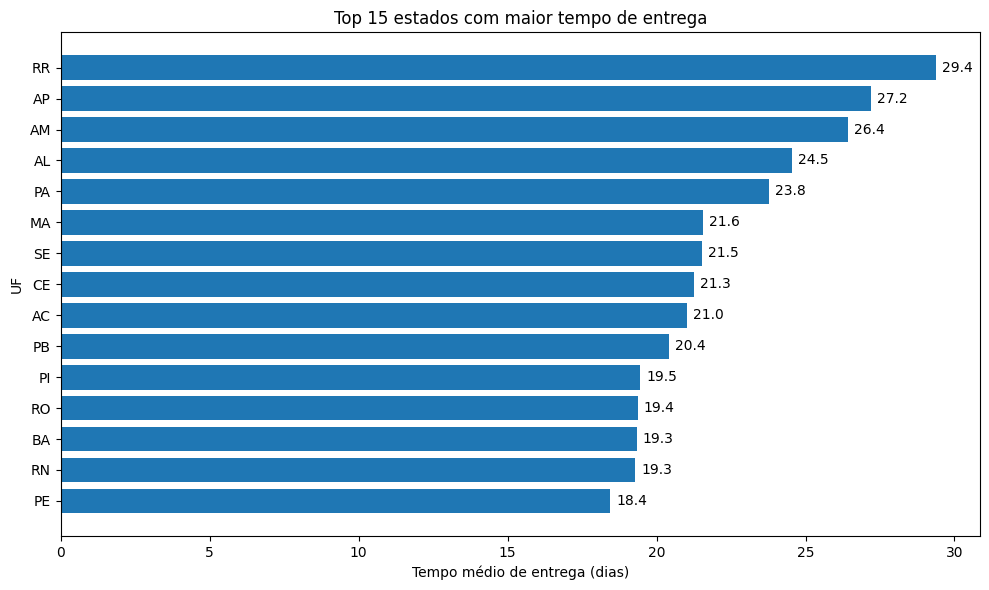

In [ ]:
# Gráfico 1: Ranking de tempo médio de entrega por estado.
top15 = (
    resumo_estados
    .sort_values('tempo_entrega_real', ascending=False)
    .head(15)
    .sort_values('tempo_entrega_real')
)

plt.figure(figsize=(10, 6))
plt.barh(top15['customer_state'], top15['tempo_entrega_real'])
plt.title('Top 15 estados com maior tempo de entrega')
plt.xlabel('Tempo médio de entrega (dias)')
plt.ylabel('UF')

for i, v in enumerate(top15['tempo_entrega_real']):
    plt.text(v + 0.2, i, f'{v:.1f}', va='center')

plt.tight_layout()

plt.savefig('ranking_atraso_por_estado.png', bbox_inches='tight', dpi=300)

plt.show()


8. Criando o gráfico de custo vs performance

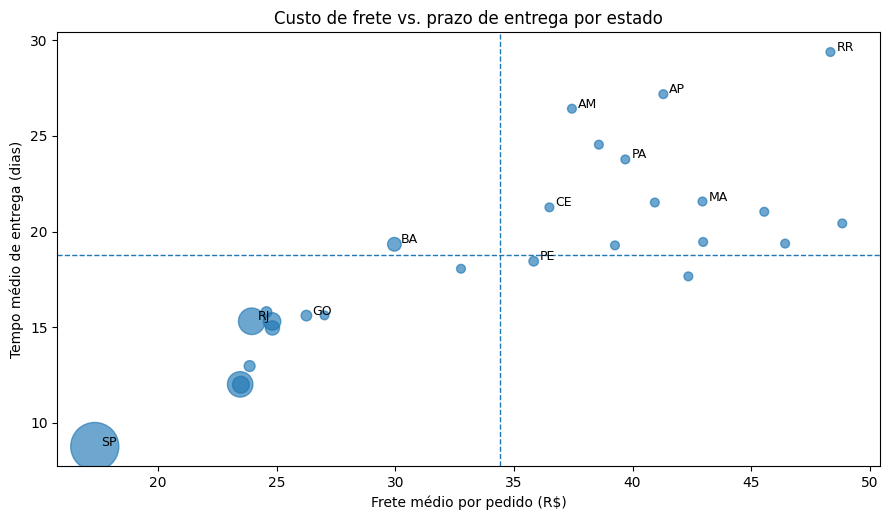

In [ ]:
# Gráfico 2: Custo de frete vs. prazo de entrega por estado.
# Aqui o frete é o frete médio por pedido, calculado pela soma do freight_value dos itens de cada order_id.

plt.figure(figsize=(9, 5.3))

sizes = np.clip(
    resumo_estados['qtd_pedidos'] / resumo_estados['qtd_pedidos'].max() * 1200,
    40,
    1200
)

plt.scatter(
    resumo_estados['frete_medio'],
    resumo_estados['tempo_entrega_real'],
    s=sizes,
    alpha=0.65
)

# Etiquetas dos estados mais importantes para a narrativa executiva.
estados_rotulados = ['SP', 'RJ', 'BA', 'PE', 'MA', 'GO', 'AM', 'PA', 'CE', 'RR', 'AP']
for _, r in resumo_estados.iterrows():
    if r['customer_state'] in estados_rotulados:
        plt.text(
            r['frete_medio'] + 0.25,
            r['tempo_entrega_real'] + 0.05,
            r['customer_state'],
            fontsize=9
        )

plt.axvline(resumo_estados['frete_medio'].mean(), linestyle='--', linewidth=1)
plt.axhline(resumo_estados['tempo_entrega_real'].mean(), linestyle='--', linewidth=1)
plt.title('Custo de frete vs. prazo de entrega por estado')
plt.xlabel('Frete médio por pedido (R$)')
plt.ylabel('Tempo médio de entrega (dias)')
plt.tight_layout()

plt.savefig('custo_vs_performance_logistica.png', bbox_inches='tight', dpi=300)

plt.show()


9. Incluindo dados externos

In [ ]:
# Criando um dicionário com participação aproximada no PIB por estado.
dados_pib = {
    'SP': 31.2,
    'RJ': 10.2,
    'MG': 8.8,
    'RS': 6.4,
    'PR': 6.4,
    'SC': 4.6,
    'BA': 3.9,
    'DF': 3.7,
    'GO': 2.7,
    'PE': 2.5,
    'PA': 2.2,
    'CE': 2.1,
    'MT': 1.8,
    'ES': 1.6,
    'MS': 1.4,
    'MA': 1.3,
    'AM': 1.3
}

resumo_estrategico = resumo_estados.copy()
resumo_estrategico['participacao_pib_percent'] = resumo_estrategico['customer_state'].map(dados_pib)

resumo_estrategico.head()


,customer_state,tempo_entrega_real,tempo_vendedor_postar,tempo_transito_logistica,frete_medio,ticket_medio,qtd_pedidos,atraso_medio,review_score,participacao_pib_percent
21,RR,29.387546,3.743370,25.644176,48.342683,172.133415,41,-16.594598,3.902439,NaN
3,AP,27.185068,3.521544,23.663524,41.298507,199.624030,67,-19.059423,4.242424,NaN
2,AM,26.425991,2.906468,23.519523,37.445724,152.798897,145,-18.851817,4.243056,1.3
1,AL,24.543855,3.458623,21.085233,38.581285,198.629018,397,-8.032059,3.852792,NaN
13,PA,23.772917,3.486143,20.286773,39.696596,184.429799,946,-13.386288,3.909968,2.2


10. Criando análise de índice de oportunidade

In [ ]:
# Criando o Índice de Oportunidade.
# Fórmula simples para priorização: maior PIB relativo + maior lead time = maior oportunidade de intervenção.

resumo_estrategico['indice_oportunidade'] = (
    resumo_estrategico['participacao_pib_percent'] * resumo_estrategico['tempo_entrega_real']
) / 100

# Ordenando pelo índice de oportunidade.
resumo_estrategico = resumo_estrategico.sort_values(by='indice_oportunidade', ascending=False)

resumo_estrategico[['customer_state', 'tempo_entrega_real', 'frete_medio', 'qtd_pedidos', 'participacao_pib_percent', 'indice_oportunidade']].head(15)


,customer_state,tempo_entrega_real,frete_medio,qtd_pedidos,participacao_pib_percent,indice_oportunidade
25,SP,8.760977,17.330678,40479,31.2,2.733425
18,RJ,15.309591,23.948434,12349,10.2,1.561578
10,MG,12.011068,23.459577,11349,8.8,1.056974
22,RS,15.301782,24.804366,5343,6.4,0.979314
17,PR,11.991582,23.490817,4923,6.4,0.767461
4,BA,19.335466,29.961201,3256,3.9,0.754083
23,SC,14.960838,24.818953,3544,4.6,0.688199
13,PA,23.772917,39.696596,946,2.2,0.523004
6,DF,12.967568,23.858144,2080,3.7,0.479800
15,PE,18.448323,35.833371,1593,2.5,0.461208


11. Criando a visualização da análise de índice de oportunidade

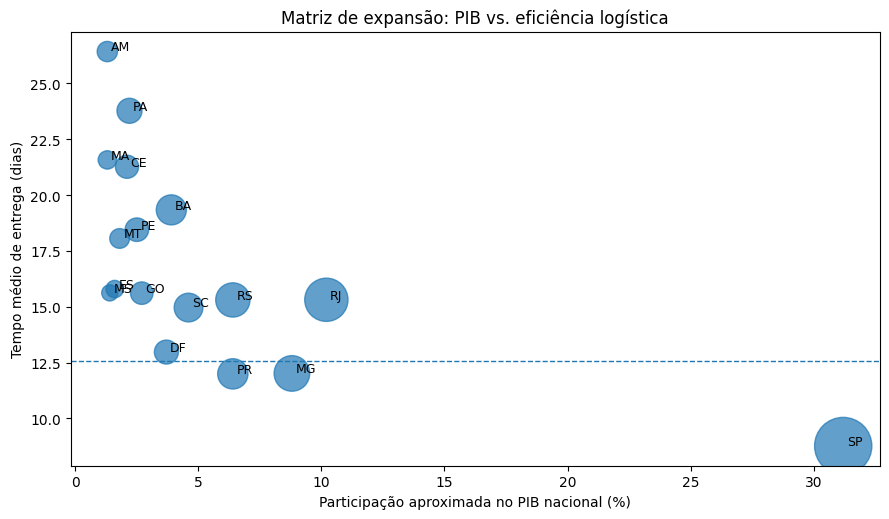

In [ ]:
# Gráfico 3: Matriz de expansão estratégica.
# Combina potencial econômico aproximado com tempo médio de entrega.

matriz = resumo_estrategico.dropna(subset=['participacao_pib_percent']).copy()

plt.figure(figsize=(9, 5.3))

sizes = np.clip(
    matriz['indice_oportunidade'] / matriz['indice_oportunidade'].max() * 1700,
    80,
    1700
)

plt.scatter(
    matriz['participacao_pib_percent'],
    matriz['tempo_entrega_real'],
    s=sizes,
    alpha=0.7
)

for _, r in matriz.iterrows():
    plt.text(
        r['participacao_pib_percent'] + 0.15,
        r['tempo_entrega_real'] + 0.05,
        r['customer_state'],
        fontsize=9
    )

plt.axhline(df_analise['tempo_entrega_real'].mean(), linestyle='--', linewidth=1)
plt.title('Matriz de expansão: PIB vs. eficiência logística')
plt.xlabel('Participação aproximada no PIB nacional (%)')
plt.ylabel('Tempo médio de entrega (dias)')
plt.tight_layout()

plt.savefig('matriz_expansao_estrategica.png', bbox_inches='tight', dpi=300)

plt.show()
